In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
customer = pd.read_csv("../data/processed/customer_final.csv")
customer.head()

,household_key,recency,frequency,monetary,avg_basket_value,total_quantity,avg_quantity,total_discount,discount_rate,unique_products,...,coupon_redeemer,campaign_rate,coupon_per_campaign,unique_departments,unique_categories,unique_brands,category_diversity,segment,segment_name,responded_to_campaign
0,1,5,86,4330.16,50.350698,1997,23.220930,697.04,0.160973,677,...,1,0.000000,0.0,0.0,0.0,0.0,0.000000,0,High-Value Loyal,1
1,2,43,45,1954.34,43.429778,834,18.533333,334.99,0.171408,546,...,0,0.177778,0.0,13.0,128.0,2.0,2.844444,1,Regular Customers,0
2,3,8,47,2653.21,56.451277,8540,181.702128,675.16,0.254469,516,...,0,0.021277,0.0,12.0,141.0,2.0,3.000000,0,High-Value Loyal,0
3,4,84,30,1200.11,40.003667,382,12.733333,115.65,0.096366,164,...,0,0.100000,0.0,12.0,110.0,2.0,3.666667,1,Regular Customers,0
4,5,8,40,779.06,19.476500,245,6.125000,118.33,0.151888,199,...,0,0.025000,0.0,9.0,63.0,2.0,1.575000,1,Regular Customers,0


In [4]:
X = customer.drop(columns=[
    "responded_to_campaign",
    "household_key",
    "coupon_redemptions",
    "coupon_rate",
    "coupon_redeemer",
    "campaign_rate",
    "coupon_per_campaign",
    "segment",
    "segment_name"
])

y = customer["responded_to_campaign"]

In [5]:
print(X.shape)
print(y.value_counts())

(2500, 24)
responded_to_campaign
0    2066
1     434
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(2000, 24)
(500, 24)


In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [8]:
categorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical))
print("Numeric:", list(numeric))

Categorical: ['classification_1', 'classification_2', 'classification_3', 'HOMEOWNER_DESC', 'classification_5', 'classification_4', 'KID_CATEGORY_DESC']
Numeric: ['recency', 'frequency', 'monetary', 'avg_basket_value', 'total_quantity', 'avg_quantity', 'total_discount', 'discount_rate', 'unique_products', 'shopping_days', 'spend_per_day', 'campaigns_received', 'campaign_types', 'unique_departments', 'unique_categories', 'unique_brands', 'category_diversity']


C:\Users\VARAD\AppData\Local\Temp\ipykernel_37536\2181701980.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = X.select_dtypes(include="object").columns


In [9]:
preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ],
    remainder="passthrough"
)

In [10]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(2000, 64)
(500, 64)


In [11]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Data Science\CONSUMERIQ\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [13]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.842


In [15]:
print("Accuracy:", accuracy)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.842
Precision: 0.6111111111111112
Recall: 0.25287356321839083
F1 Score: 0.35772357723577236


In [16]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.820461439982188


In [17]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [20]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.846
Precision: 0.6041666666666666
Recall: 0.3333333333333333
F1 Score: 0.42962962962962964
ROC-AUC: 0.8602599426678913


In [21]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [22]:
balanced_pred = rf_balanced.predict(X_test)
balanced_prob = rf_balanced.predict_proba(X_test)[:, 1]

In [23]:
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall:", recall_score(y_test, balanced_pred))
print("F1 Score:", f1_score(y_test, balanced_pred))
print("ROC-AUC:", roc_auc_score(y_test, balanced_prob))

Accuracy: 0.838
Precision: 0.53125
Recall: 0.5862068965517241
F1 Score: 0.5573770491803278
ROC-AUC: 0.8617767387492695


In [24]:
importance = rf_balanced.feature_importances_

features = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
49,remainder__monetary,0.124991
53,remainder__total_discount,0.120079
55,remainder__unique_products,0.087618
56,remainder__shopping_days,0.071097
48,remainder__frequency,0.052099
63,remainder__category_diversity,0.045635
51,remainder__total_quantity,0.043727
57,remainder__spend_per_day,0.040590
50,remainder__avg_basket_value,0.039608
54,remainder__discount_rate,0.036842


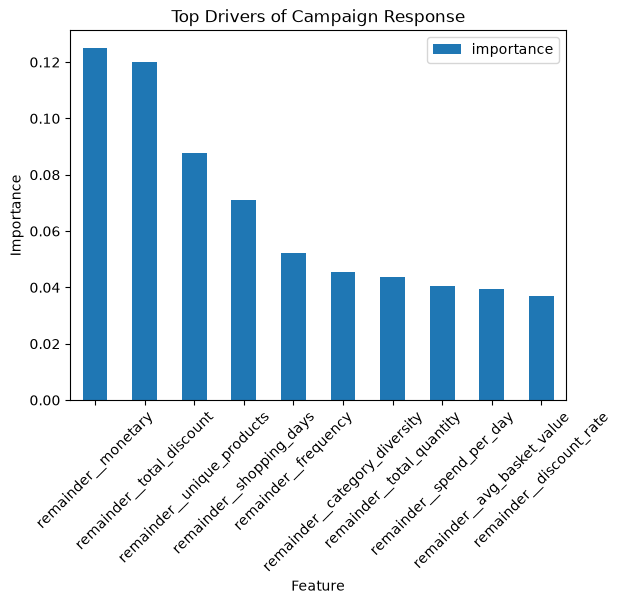

In [29]:
top_features = importance_df.head(10)

top_features.plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.title("Top Drivers of Campaign Response")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

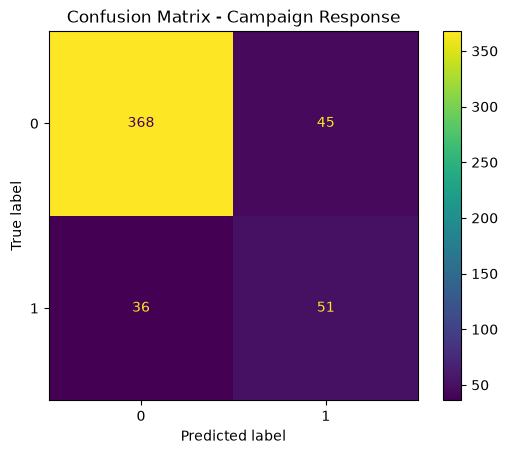

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, balanced_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix - Campaign Response")
plt.show()

In [33]:
import joblib

joblib.dump(rf_balanced, "../models/campaign_response_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [34]:
import os

print(os.path.exists("../models/campaign_response_model.pkl"))

True


In [35]:
segment_campaign = customer.groupby("segment_name").agg(
    customers=("household_key", "count"),
    response_rate=("responded_to_campaign", "mean"),
    avg_spending=("monetary", "mean"),
    avg_frequency=("frequency", "mean")
)

segment_campaign["response_rate"] = segment_campaign["response_rate"] * 100

segment_campaign.sort_values("response_rate", ascending=False).round(2)

,customers,response_rate,avg_spending,avg_frequency
segment_name,,,,
VIP Power Customers,369,49.05,8591.96,305.90
High-Value Loyal,507,28.80,4452.67,82.59
Regular Customers,1560,6.86,1674.70,77.71
At-Risk Customers,64,0.00,265.40,7.95


In [36]:
business_summary = customer.groupby("segment_name").agg(
    customers=("household_key", "count"),
    avg_spending=("monetary", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_recency=("recency", "mean"),
    campaign_response_rate=("responded_to_campaign", "mean")
)

business_summary["campaign_response_rate"] *= 100

business_summary = business_summary.sort_values(
    "avg_spending",
    ascending=False
)

business_summary.round(2)

,customers,avg_spending,avg_frequency,avg_recency,campaign_response_rate
segment_name,,,,,
VIP Power Customers,369,8591.96,305.90,4.83,49.05
High-Value Loyal,507,4452.67,82.59,15.19,28.80
Regular Customers,1560,1674.70,77.71,22.33,6.86
At-Risk Customers,64,265.40,7.95,306.59,0.00


In [37]:
business_summary.to_csv(
    "../data/processed/customer_segment_business_summary.csv"
)

print("Business summary saved successfully.")

Business summary saved successfully.


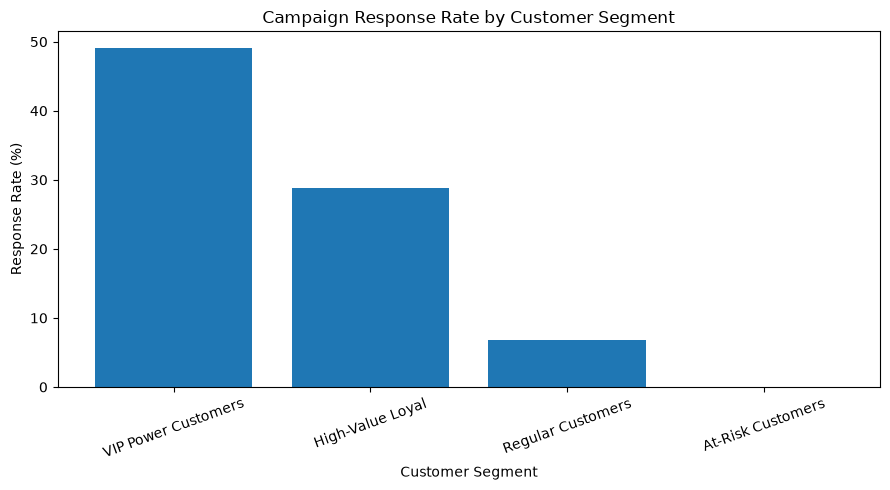

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    business_summary.index,
    business_summary["campaign_response_rate"]
)

plt.title("Campaign Response Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()